# Imports:

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
import pyarrow 
import pyarrow.parquet

c:\Users\thoma\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Dataset:

For this project we use the Smell Pittsburgh dataset:

In [2]:
df_irregular = pd.read_csv("data/smell.csv")

# Loading external models:

This model is trained on data that includes stopwords and capital letters. So there is minimal extra preprocessing required to make embeddings from the textual data from the dataset.

In [3]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9126.53it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Text preprocessing

We first try to make an TF-IDF and plot these using PCA.

In order to visualize the data from both the TF-IDF and embeddings, we will use <i>Priciple Component Analasys</i> (PCA) to reduce the dimensions of the textual data.

Make the 'date & time' column the index of the new dataset. This is done in order to resample the data in the next step. The column is also made into a <i>datetime</i>, to ensure correct interpertation by pandas.

In [4]:
df_irregular["date & time"] = pd.to_datetime(df_irregular["date & time"], utc=True)
df_irregular = df_irregular.set_index("date & time").sort_index()

We combine the three different column to create a richer and easier context for better drift detection. Another technique used was to first make the sentence embeddings and then combine them, but this yielded similar results whilst being slower. See the <i>notebook_first_embeddings.ipynb</i> file.

In [5]:
df_irregular["combined"] = df_irregular["smell description"].fillna("") + " " + df_irregular["symptoms"].fillna("") + " " + df_irregular["additional comments"].fillna("")

Making sure the textfields contain strings or NaN for correct implementation of the embeddings and averaging later.

In [6]:
df_irregular["smell description"] = df_irregular["smell description"].replace(0, np.nan)
df_irregular["smell description"] = df_irregular["smell description"].astype("string")
df_irregular["symptoms"] = df_irregular["symptoms"].replace(0, np.nan)
df_irregular["symptoms"] = df_irregular["symptoms"].astype("string")
df_irregular["additional comments"] = df_irregular["additional comments"].replace(0, np.nan)
df_irregular["additional comments"] = df_irregular["additional comments"].astype("string")
df_irregular["combined"] = df_irregular["combined"].replace(0, np.nan)
df_irregular["combined"] = df_irregular["combined"].astype("string")

In [7]:
df_text = df_irregular.copy()

## Implementing TF-IDF

TF-IDF works best with standard preprocessing. Stopwords are removed as part of the preprocessing

In [8]:
tfidf = TfidfVectorizer(stop_words="english", max_features=500)

combined = tfidf.fit_transform(df_text["combined"].fillna(""))

Plotting the TF-IDF using PCA

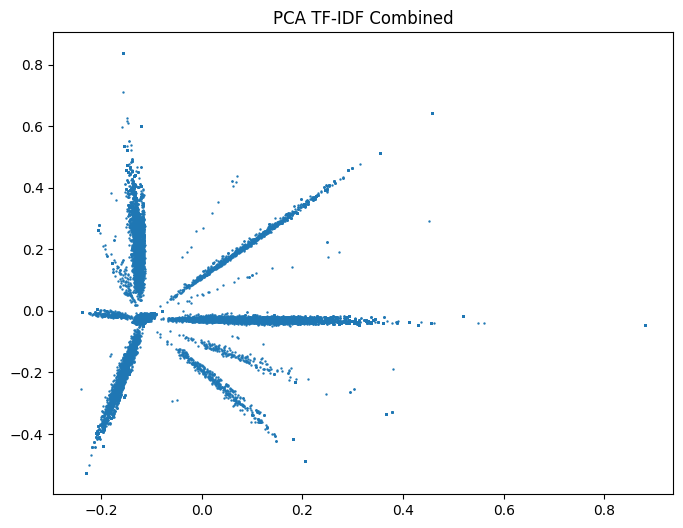

In [9]:
pca = PCA(n_components=2).fit_transform(combined.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Combined")
plt.scatter(pca[:, 0], pca[:, 1], s=0.5)

In the plot above we can see a lot of spikes in the dataset. This is suboptimal for drift detection, since we see very little change in directions. Thus a TF-IDF isn't suited for our problem.  We can validate this by printing the most used words. We can see from this that words like sulfur/rotten/eggs appear frequently. These words are contextually similar but appear in completely different spikes. A sentence embedding yields better results.

In [10]:
tfidf_names = tfidf.get_feature_names_out()
score = np.asarray(combined.mean(axis=0)).ravel()

word_score = pd.DataFrame({"word": tfidf_names, "score": score})

print(word_score.sort_values(by="score", ascending=False).head(10))

           word     score
194  industrial  0.122185
416      sulfur  0.063618
169    headache  0.042471
346      rotten  0.039290
113        eggs  0.038400
43      burning  0.030096
435      throat  0.027797
378       smell  0.022151
392        sore  0.017968
206  irritation  0.017694


## Sentence Embeddings

Embedding the sentences using the preloaded model:

In [11]:
embeddings = model.encode(df_text["combined"].tolist())

For visualisation purposes we use a PCA

In [12]:
embeddings_2d  = PCA(n_components=2).fit_transform(embeddings)

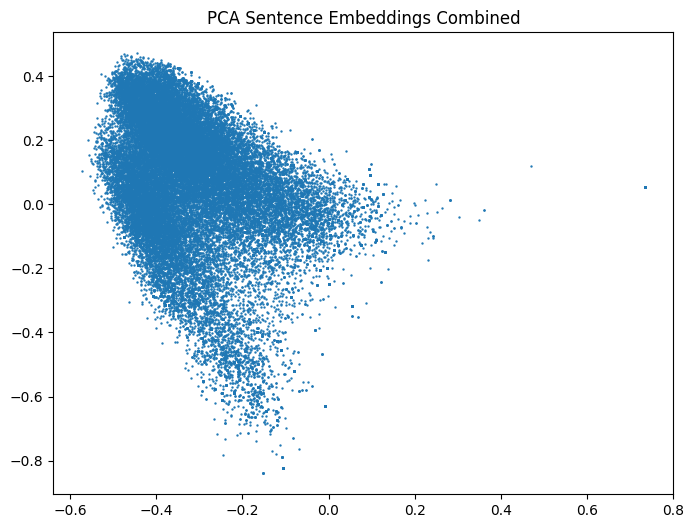

In [13]:
plt.figure(figsize=(8,6))
plt.title("PCA Sentence Embeddings Combined")
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=0.5)

The spikes of the TF-IDF are gone, similar words are now better grouped together.

# Regular Dataset with PCA

Creating the regular baseline dataset from the Smell Pittsburgh dataset. The PCA reduces the dimensions of the sentence embeddings to 2 dimensions, making it quicker to run, but losing contextual information.

Initiliaze the regular sampled dataset as a copy of the irregular dataset.

In [14]:
df_regular = df_irregular.copy()

## Adding the text data to the regular dataset

We first combine the data together as done with the TF-IDF, afterwards we resample the data to hourly. If there are more reports with text, all the text gets added into one cell.

In [15]:
df_temp = df_irregular.copy()

Creating the embeddings of the text:

In [16]:
df_temp["text_emb_1"] = embeddings_2d[:, 0]
df_temp["text_emb_2"] = embeddings_2d[:, 1]

Resampling of the dataset:

In [17]:
df_regular_pca_2 = df_temp.resample("1h").agg(
    count = ("smell value", "size"),
    mean_smell = ("smell value", "mean"),
    latitude_mean = ("skewed latitude", "mean"),
    latitude_std = ("skewed latitude", "std"),
    longitude_mean = ("skewed longitude", "mean"),
    longitude_std = ("skewed longitude", "std"),
    text_emb_1_mean = ("text_emb_1", "mean"),
    text_emb_1_std = ("text_emb_1", "std"),
    text_emb_2_mean = ("text_emb_2", "mean"),
    text_emb_2_std = ("text_emb_2", "std"),
    )

In [18]:
df_regular_pca_2 = df_regular_pca_2.fillna(0)

Saving the dataset as an .csv

In [19]:
df_regular_pca_2.to_csv("data/smell_regular_pca_2.csv")

# Irregular dataset with PCA

Same principle as the regular dataset, using PCA to reduce to two dimensions.

In [20]:
df_irregular_pca_2 = df_irregular.copy()

In [21]:
embeddings_2d = PCA(n_components=2).fit_transform(embeddings)

df_irregular_pca_2["text_emb_1"] = embeddings_2d[:, 0]
df_irregular_pca_2["text_emb_2"] = embeddings_2d[:, 1]

In [22]:
df_irregular_pca_2 = df_irregular.fillna(0)

In [23]:
df_irregular_pca_2.to_csv("data/smell_irregular_pca_2.csv")

## Irregular dataset with 100 dimensions

In [24]:
df_irregular_100d = df_irregular.copy()

In [25]:
embeddings_100d = PCA(n_components=100).fit_transform(embeddings)

In [26]:
df_irregular_100d["embedding"] = embeddings_100d.tolist()

In [27]:
df_irregular_100d.to_parquet("data/smell_irregular_pca_100.parquet")

## Irregular dataset without PCA

In [28]:
df_irregular["embedding"] = embeddings.tolist()

In [29]:
df_irregular.to_parquet("data/smell_irregular.parquet")

## Regular dataset without PCA

In [30]:
df_regular = df_irregular.copy()

In [31]:
df_regular = df_regular.resample("1h").agg(
    count = ("smell value", "size"),
    mean_smell = ("smell value", "mean"),
    latitude_mean = ("skewed latitude", "mean"),
    latitude_std = ("skewed latitude", "std"),
    longitude_mean = ("skewed longitude", "mean"),
    longitude_std = ("skewed longitude", "std"),
    text_emb_mean = ("embedding",
        lambda x: (np.mean(np.stack(vals), axis=0)
            if (vals := [v for v in x if v is not None and len(v) > 0])
            else np.nan
        )
    ),

    text_emb_std = ("embedding",
        lambda x: (np.std(np.stack(vals), axis=0)
            if (vals := [v for v in x if v is not None and len(v) > 0])
            else np.nan
        )
    ),

    )

In [32]:
df_regular.to_parquet("data/smell_regular.parquet")

In [33]:
df_regular_100d = df_irregular_100d.copy()

In [34]:
df_regular_100d  = df_regular_100d.resample("1h").agg(
    count = ("smell value", "size"),
    mean_smell = ("smell value", "mean"),
    latitude_mean = ("skewed latitude", "mean"),
    latitude_std = ("skewed latitude", "std"),
    longitude_mean = ("skewed longitude", "mean"),
    longitude_std = ("skewed longitude", "std"),
    text_emb_mean = ("embedding",
        lambda x: (np.mean(np.stack(vals), axis=0)
            if (vals := [v for v in x if v is not None and len(v) > 0])
            else np.nan
        )
    ),

    text_emb_std = ("embedding",
        lambda x: (np.std(np.stack(vals), axis=0)
            if (vals := [v for v in x if v is not None and len(v) > 0])
            else np.nan
        )
    ),

    )

In [35]:
df_regular_100d.to_parquet("data/smell_regular_100.parquet")

# Aggregated irregular dataset

In [36]:
window = df_irregular.rolling("6h")

In [37]:
df_rolling = pd.DataFrame(index=df_irregular.index)

In [38]:
df_rolling["count"] = window["smell value"].count()
df_rolling["mean_smell"] = window["smell value"].mean()

In [39]:
df_rolling["latitude_mean"] = window["skewed latitude"].mean()
df_rolling["longitude_mean"] = window["skewed longitude"].mean()
df_rolling["latitude_std"] = window["skewed latitude"].std()
df_rolling["longitude_std"] = window["skewed longitude"].std()

In [40]:
df_rolling_100d = df_rolling.copy()

In [41]:
df_rolling["embedding"] = embeddings.tolist()

In [42]:
df_rolling.to_parquet("data/smell_irregular_rolling.parquet")

In [43]:
df_rolling_100d["embedding"] = embeddings_100d.tolist()

In [44]:
df_rolling_100d.to_parquet("data/smell_irregular_rolling_100.parquet")

In [45]:
print(df_rolling_100d.head())

                           count  mean_smell  latitude_mean  longitude_mean  \
date & time                                                                   
2019-12-31 23:56:50+00:00    1.0         3.0      40.557110      -80.059578   
2020-01-01 03:48:06+00:00    2.0         3.0      40.490124      -79.989983   
2020-01-01 04:19:54+00:00    3.0         3.0      40.453787      -79.946983   
2020-01-01 05:48:02+00:00    4.0         3.0      40.417273      -79.925465   
2020-01-01 12:56:51+00:00    1.0         3.0      40.307781      -79.860908   

                           latitude_std  longitude_std  \
date & time                                              
2019-12-31 23:56:50+00:00           NaN            NaN   
2020-01-01 03:48:06+00:00      0.094733       0.098423   
2020-01-01 04:19:54+00:00      0.091914       0.101933   
2020-01-01 05:48:02+00:00      0.104716       0.093697   
2020-01-01 12:56:51+00:00           NaN            NaN   

                                       

In [46]:
print(df_rolling.head())

                           count  mean_smell  latitude_mean  longitude_mean  \
date & time                                                                   
2019-12-31 23:56:50+00:00    1.0         3.0      40.557110      -80.059578   
2020-01-01 03:48:06+00:00    2.0         3.0      40.490124      -79.989983   
2020-01-01 04:19:54+00:00    3.0         3.0      40.453787      -79.946983   
2020-01-01 05:48:02+00:00    4.0         3.0      40.417273      -79.925465   
2020-01-01 12:56:51+00:00    1.0         3.0      40.307781      -79.860908   

                           latitude_std  longitude_std  \
date & time                                              
2019-12-31 23:56:50+00:00           NaN            NaN   
2020-01-01 03:48:06+00:00      0.094733       0.098423   
2020-01-01 04:19:54+00:00      0.091914       0.101933   
2020-01-01 05:48:02+00:00      0.104716       0.093697   
2020-01-01 12:56:51+00:00           NaN            NaN   

                                       

In [47]:
print(df_irregular.head())

                           epoch time  smell value  skewed latitude  \
date & time                                                           
2019-12-31 23:56:50+00:00  1577836610            3        40.557110   
2020-01-01 03:48:06+00:00  1577850486            3        40.423138   
2020-01-01 04:19:54+00:00  1577852394            3        40.381115   
2020-01-01 05:48:02+00:00  1577857682            3        40.307728   
2020-01-01 12:56:51+00:00  1577883411            3        40.307781   

                           skewed longitude  zipcode  \
date & time                                            
2019-12-31 23:56:50+00:00        -80.059578    15237   
2020-01-01 03:48:06+00:00        -79.920387    15217   
2020-01-01 04:19:54+00:00        -79.860985    15110   
2020-01-01 05:48:02+00:00        -79.860908    15037   
2020-01-01 12:56:51+00:00        -79.860908    15037   

                                                         smell description  \
date & time                    

In [61]:
df_regular_100d["text_emb_mean"].apply(lambda x: np.shape(x)).value_counts()

text_emb_mean
()        26804
(100,)    25801
Name: count, dtype: int64

In [48]:
print(df_regular.head())

                           count  mean_smell  latitude_mean  latitude_std  \
date & time                                                                 
2019-12-31 23:00:00+00:00      1         3.0      40.557110           NaN   
2020-01-01 00:00:00+00:00      0         NaN            NaN           NaN   
2020-01-01 01:00:00+00:00      0         NaN            NaN           NaN   
2020-01-01 02:00:00+00:00      0         NaN            NaN           NaN   
2020-01-01 03:00:00+00:00      1         3.0      40.423138           NaN   

                           longitude_mean  longitude_std  \
date & time                                                
2019-12-31 23:00:00+00:00      -80.059578            NaN   
2020-01-01 00:00:00+00:00             NaN            NaN   
2020-01-01 01:00:00+00:00             NaN            NaN   
2020-01-01 02:00:00+00:00             NaN            NaN   
2020-01-01 03:00:00+00:00      -79.920387            NaN   

                                       

## Visualizing the data

Different plots of the data, based on location and comments a day:

In [49]:
print(df_irregular.columns)

Index(['epoch time', 'smell value', 'skewed latitude', 'skewed longitude',
       'zipcode', 'smell description', 'symptoms', 'additional comments',
       'combined', 'embedding'],
      dtype='object')


## Irregular Sampled

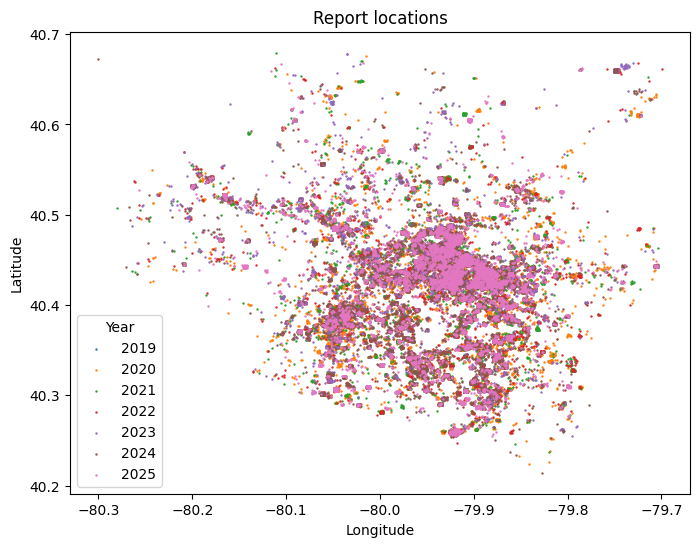

In [50]:
df_irregular["year"] = pd.to_datetime(df_irregular.index, errors="coerce", utc=True).year

plt.figure(figsize=(8,6))

for i in df_irregular["year"].dropna().unique():
    subset = df_irregular[df_irregular["year"] == i]
    
    plt.scatter(subset["skewed longitude"], subset["skewed latitude"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

## Regular Sampled

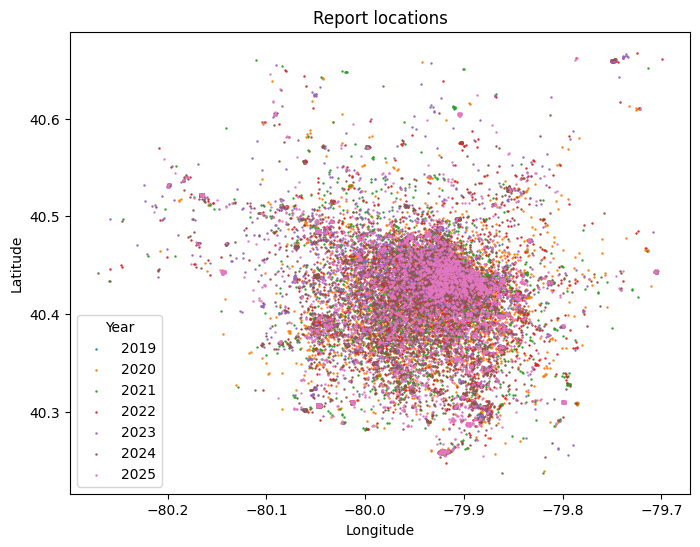

In [51]:
df_regular["year"] = pd.to_datetime(df_regular.index, errors="coerce", utc=True).year

plt.figure(figsize=(8,6))

for i in df_regular["year"].dropna().unique():
    subset = df_regular[df_regular["year"] == i]
    
    plt.scatter(subset["longitude_mean"], subset["latitude_mean"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()